In [3]:
import pandas as pd
import numpy as np

print("KROK 1: Wczytywanie i Optymalizacja Big Data")

df = pd.read_csv('spotify-tracks.csv')

# Zbiory z Kaggle często mają kolumnę z indeksem
if 'Unnamed: 0' in df.columns:
    df = df.drop('Unnamed: 0', axis=1)

df = df.dropna()

# Początkowe zużycie pamięci
mem_start = df.memory_usage(deep=True).sum() / (1024**2)
print(f"Początkowe zużycie pamięci RAM: {mem_start:.2f} MB")


# Optymalizacja

df_opt = df.copy()

for kolumna in df_opt.columns:
    typ = df_opt[kolumna].dtype

    # Optymalizacja liczb całkowitych
    if str(typ).startswith('int'):
        df_opt[kolumna] = pd.to_numeric(df_opt[kolumna], downcast='integer')

    # Optymalizacja ułamków
    elif str(typ).startswith('float'):
        df_opt[kolumna] = pd.to_numeric(df_opt[kolumna], downcast='float')

    # Optymalizacja tekstu
    elif str(typ) == 'object':
        unikalne = df_opt[kolumna].nunique()
        wszystkie = len(df_opt)

        if unikalne / wszystkie < 0.1:
            df_opt[kolumna] = df_opt[kolumna].astype('category')

# Wynik po optymalizacji
mem_end = df_opt.memory_usage(deep=True).sum() / (1024**2)
oszczednosc = (1 - (mem_end / mem_start)) * 100

print(f"Zużycie pamięci po optymalizacji: {mem_end:.2f} MB")
print(f"Udało się zaoszczędzić: {oszczednosc:.2f}% RAM\n")

df = df_opt
del df_opt

print("Kształt ramki:", df.shape)

KROK 1: Wczytywanie i Optymalizacja Big Data
Początkowe zużycie pamięci RAM: 49.66 MB
Zużycie pamięci po optymalizacji: 42.27 MB
Udało się zaoszczędzić: 14.89% RAM

Kształt ramki: (113999, 20)


In [4]:
import category_encoders as ce

print("KROK 2: Binary Encoding\n")

# 1. Usuwamy kolumny tekstowe, które nie przydadzą się do uczenia maszynowego
kolumny_do_usuniecia = ['track_id', 'artists', 'album_name', 'track_name']
df = df.drop(columns=kolumny_do_usuniecia)
print(f"Po usunięciu zostało: {df.shape[1]} cech")

# 2. Kodowanie zmiennej explicit
df['explicit'] = df['explicit'].astype(int)

# 3. Binary Encoding dla 'track_genre'
# One-Hot Encoding stworzyłby 114 nowych kolumn
# Binary Encoding załatwi to w zaledwie 7 kolumnach
encoder = ce.BinaryEncoder(cols=['track_genre'])
df = encoder.fit_transform(df)

print(f"Kształt ramki po kodowaniu Binary Encoding: {df.shape}\n")

print("KROK 3: Wykrywanie Wartości Odstających (IQR)\n")

def policz_odstajace_iqr(kolumna):
    Q1 = kolumna.quantile(0.25)
    Q3 = kolumna.quantile(0.75)
    IQR = Q3 - Q1
    dolna_granica = Q1 - 1.5 * IQR
    gorna_granica = Q3 + 1.5 * IQR

    return ((kolumna < dolna_granica) | (kolumna > gorna_granica)).sum()

kolumny_audio = ['popularity', 'duration_ms', 'danceability', 'energy', 'loudness',
                 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']

print("Liczba anomalii w poszczególnych cechach:")
anomalie_dict = {}
for kol in kolumny_audio:
    liczba_anomalii = policz_odstajace_iqr(df[kol])
    anomalie_dict[kol] = liczba_anomalii
    print(f"- {kol}: {liczba_anomalii} wartości odstających")

KROK 2: Binary Encoding

Po usunięciu zostało: 16 cech
Kształt ramki po kodowaniu Binary Encoding: (113999, 22)

KROK 3: Wykrywanie Wartości Odstających (IQR)

Liczba anomalii w poszczególnych cechach:
- popularity: 2 wartości odstających
- duration_ms: 5616 wartości odstających
- danceability: 620 wartości odstających
- energy: 0 wartości odstających
- loudness: 6174 wartości odstających
- speechiness: 13211 wartości odstających
- acousticness: 0 wartości odstających
- instrumentalness: 25246 wartości odstających
- liveness: 8642 wartości odstających
- valence: 0 wartości odstających
- tempo: 617 wartości odstających


Wykresy pudełkowe



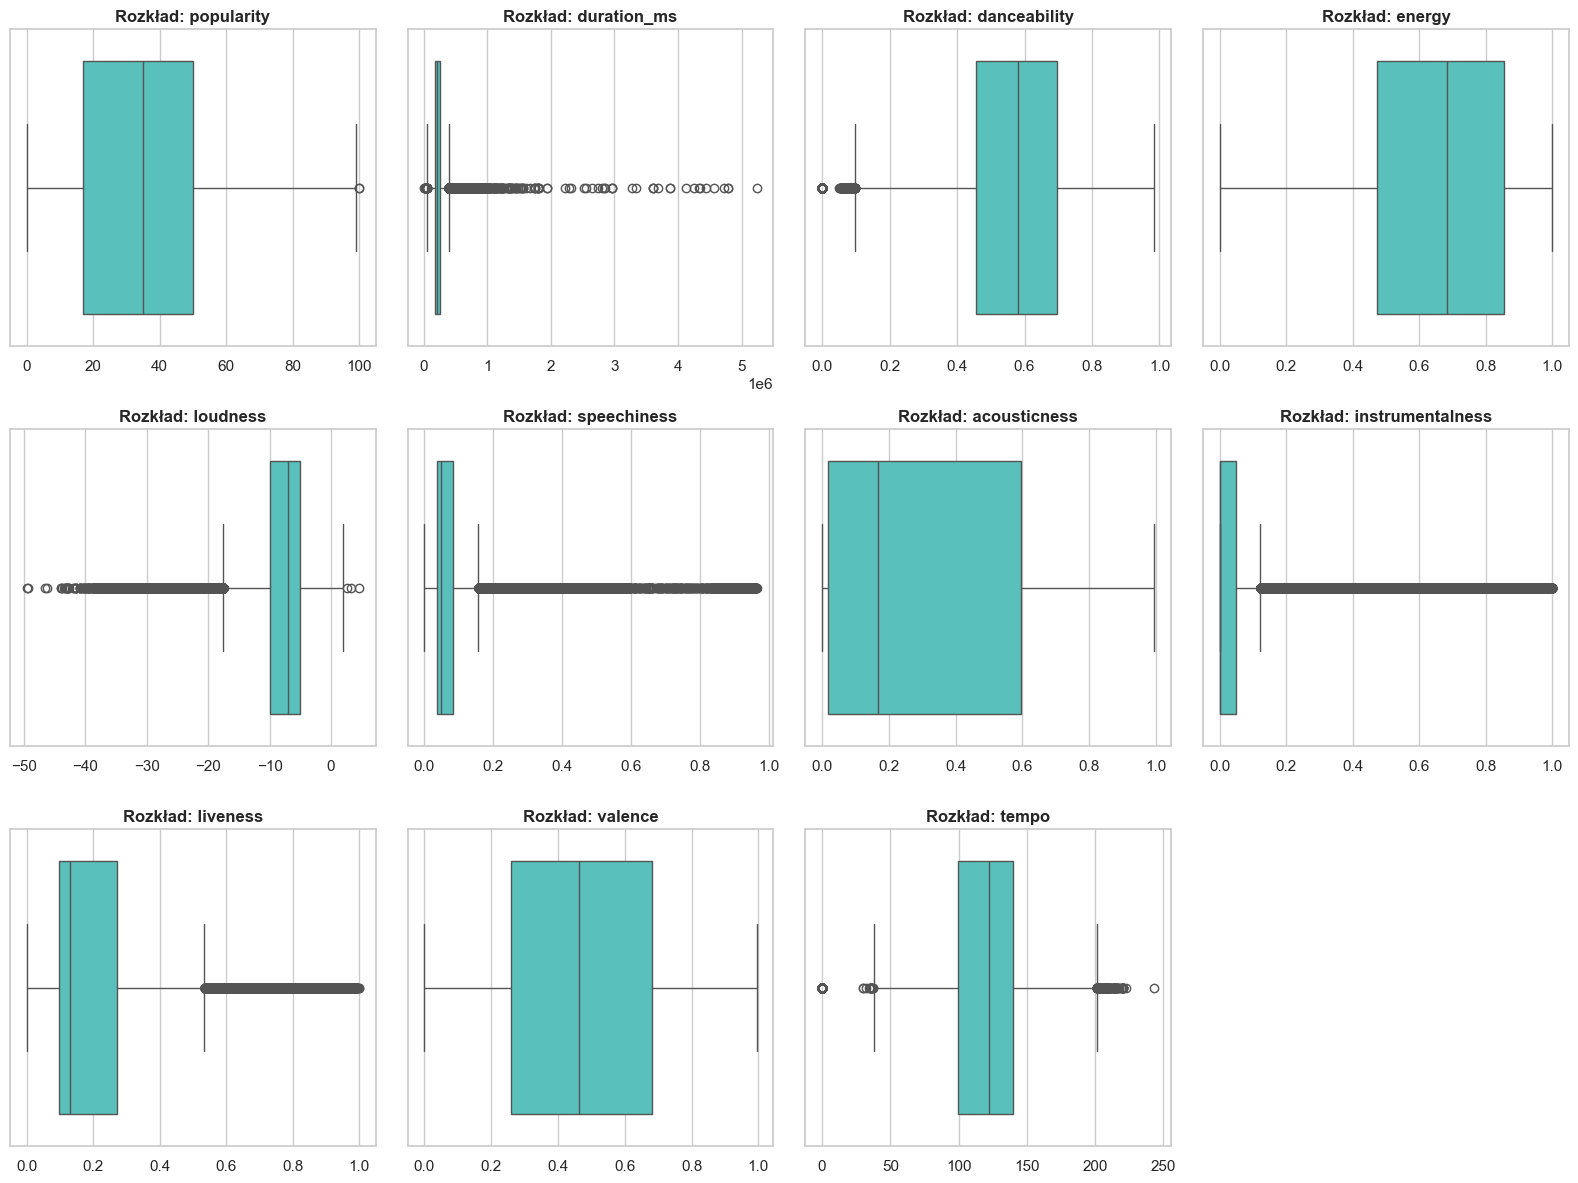

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Wykresy pudełkowe\n")

kolumny_audio = ['popularity', 'duration_ms', 'danceability', 'energy', 'loudness',
                 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']

sns.set_theme(style="whitegrid")


fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()


for i, kolumna in enumerate(kolumny_audio):

    sns.boxplot(x=df[kolumna], ax=axes[i], color='mediumturquoise')

    axes[i].set_title(f"Rozkład: {kolumna}", fontsize=12, fontweight='bold')
    axes[i].set_xlabel("")

fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import GridSearchCV
import time

print("KROK 4-6: Podział -> Skalowanie -> PCA -> Model\n" + "-"*50)

# 1. Dzielimy dane
X = df.drop(columns=['explicit'])
y = df['explicit']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

kol_audio = ['popularity', 'duration_ms', 'danceability', 'energy', 'loudness',
             'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']
kol_inne = [col for col in X.columns if col not in kol_audio]

# 2. Skalowanie
scaler = RobustScaler()
X_train_audio_scaled = scaler.fit_transform(X_train[kol_audio])
X_test_audio_scaled = scaler.transform(X_test[kol_audio])

# 3. PCA
pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train_audio_scaled)
X_test_pca = pca.transform(X_test_audio_scaled)

# 4. Łączymy zredukowane audio z powrotem z naszymi zakodowanymi gatunkami
import numpy as np
X_train_final = np.hstack((X_train[kol_inne].values, X_train_pca))
X_test_final = np.hstack((X_test[kol_inne].values, X_test_pca))

print(f"Kształt przed modelem: {X_train_final.shape}")

# 5. Optymalizacja Modelu (GridSearchCV)

# Definiujemy parametry do sprawdzenia
parametry_grid = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance']
}

# Inicjujemy podstawowy model i siatkę poszukiwań
knn_podstawowy = KNeighborsClassifier()
grid_search = GridSearchCV(estimator=knn_podstawowy, param_grid=parametry_grid,
                           cv=3, scoring='accuracy', n_jobs=-1)

start_time = time.time()
grid_search.fit(X_train_final, y_train)
czas_grid = time.time() - start_time

print("\nNAJLEPSZE ZNALEZIONE PARAMETRY:")
print(grid_search.best_params_)

print("\nWYNIKI NAJLEPSZEGO MODELU NA DANYCH TESTOWYCH:")
najlepszy_model = grid_search.best_estimator_
y_pred = najlepszy_model.predict(X_test_final)

print(classification_report(y_test, y_pred, zero_division=0))

KROK 4-6: Podział -> Skalowanie -> PCA -> Model
--------------------------------------------------
Kształt przed modelem: (91199, 15)

NAJLEPSZE ZNALEZIONE PARAMETRY:
{'n_neighbors': 9, 'weights': 'distance'}

WYNIKI NAJLEPSZEGO MODELU NA DANYCH TESTOWYCH:
              precision    recall  f1-score   support

           0       0.94      0.99      0.96     20904
           1       0.67      0.33      0.44      1896

    accuracy                           0.93     22800
   macro avg       0.81      0.66      0.70     22800
weighted avg       0.92      0.93      0.92     22800



In [6]:
import time
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

print("EKSPERYMENT: Wpływ redukcji wymiarów (PCA) na zoptymalizowany model\n" + "-"*65)

knn_eksperyment = KNeighborsClassifier(n_neighbors=9, weights='distance')


# PODEJŚCIE 1: Bez PCA

X_train_no_pca = np.hstack((X_train[kol_inne].values, X_train_audio_scaled))
X_test_no_pca = np.hstack((X_test[kol_inne].values, X_test_audio_scaled))

print("1. Trening modelu BEZ PCA 21 cech")
start_no_pca = time.time()
knn_eksperyment.fit(X_train_no_pca, y_train)
pred_no_pca = knn_eksperyment.predict(X_test_no_pca)
czas_no_pca = time.time() - start_no_pca
acc_no_pca = accuracy_score(y_test, pred_no_pca)

print(f"-> Czas: {czas_no_pca:.2f} s | Dokładność: {acc_no_pca*100:.2f}%\n")



# PODEJŚCIE 2: Z PCA

print("2. Trening modelu Z użyciem PCA 15 cech")
start_pca = time.time()
knn_eksperyment.fit(X_train_final, y_train)
pred_pca = knn_eksperyment.predict(X_test_final)
czas_pca = time.time() - start_pca
acc_pca = accuracy_score(y_test, pred_pca)

print(f"-> Czas: {czas_pca:.2f} s | Dokładność: {acc_pca*100:.2f}%\n")


roznica_czasu = czas_no_pca / czas_pca
roznica_acc = acc_no_pca - acc_pca

print("PODSUMOWANIE EKSPERYMENTU:")
print(f"- Czas obliczeń bez PCA wydłużył się {roznica_czasu:.2f} razy.")
print(f"- Zmiana dokładności modelu wyniosła: {roznica_acc*100:.2f} punktów procentowych.")

EKSPERYMENT: Wpływ redukcji wymiarów (PCA) na zoptymalizowany model
-----------------------------------------------------------------
1. Trening modelu BEZ PCA 21 cech
-> Czas: 2.49 s | Dokładność: 93.25%

2. Trening modelu Z użyciem PCA 15 cech
-> Czas: 5.06 s | Dokładność: 93.09%

PODSUMOWANIE EKSPERYMENTU:
- Czas obliczeń bez PCA wydłużył się 0.49 razy.
- Zmiana dokładności modelu wyniosła: 0.17 punktów procentowych.


In [1]:
import pandas as pd

print("CIEKAWOSTKI DO PROJEKTU\n")


df_eda = pd.read_csv('spotify-tracks.csv')

# 1. RANKING WULGARYZMÓW

df_eda['explicit'] = df_eda['explicit'].astype(int)
wulgaryzmy = df_eda.groupby('track_genre')['explicit'].mean() * 100
wulgaryzmy = wulgaryzmy.sort_values(ascending=False).head(10)

print("TOP 10 GATUNKÓW Z NAJWIĘKSZĄ ILOŚCIĄ WULGARYZMÓW (%):")
print(wulgaryzmy.round(2).to_string())
print("\n" + "-"*40 + "\n")


# 2. RANKING DŁUGOŚCI UTWORÓW
dlugosc_minuty = (df_eda.groupby('track_genre')['duration_ms'].mean() / 60000)

print("TOP 5 NAJDŁUŻSZYCH GATUNKÓW (średni czas w minutach):")
print(dlugosc_minuty.sort_values(ascending=False).head(5).round(2).to_string())

print("\nTOP 5 NAJKRÓTSZYCH GATUNKÓW (średni czas w minutach):")
print(dlugosc_minuty.sort_values(ascending=True).head(5).round(2).to_string())
print("\n" + "-"*40 + "\n")


# 3. RANKING TANECZNOŚCI
tanecznosc = df_eda.groupby('track_genre')['danceability'].mean().sort_values(ascending=False).head(5)

print("TOP 5 NAJBARDZIEJ TANECZNYCH GATUNKÓW (0-1):")
print(tanecznosc.round(3).to_string())

CIEKAWOSTKI DO PROJEKTU

TOP 10 GATUNKÓW Z NAJWIĘKSZĄ ILOŚCIĄ WULGARYZMÓW (%):
track_genre
comedy         65.6
emo            46.5
sad            45.0
j-dance        39.1
hardcore       32.5
hip-hop        31.9
funk           30.4
dancehall      30.2
metalcore      29.1
death-metal    25.1

----------------------------------------

TOP 5 NAJDŁUŻSZYCH GATUNKÓW (średni czas w minutach):
track_genre
detroit-techno    6.20
minimal-techno    6.15
chicago-house     6.11
breakbeat         5.36
iranian           5.33

TOP 5 NAJKRÓTSZYCH GATUNKÓW (średni czas w minutach):
track_genre
grindcore    2.23
children     2.32
study        2.36
sad          2.56
disney       2.60

----------------------------------------

TOP 5 NAJBARDZIEJ TANECZNYCH GATUNKÓW (0-1):
track_genre
kids             0.779
chicago-house    0.766
reggaeton        0.759
latino           0.757
reggae           0.745


Generowanie wykresów analitycznych (EDA)...



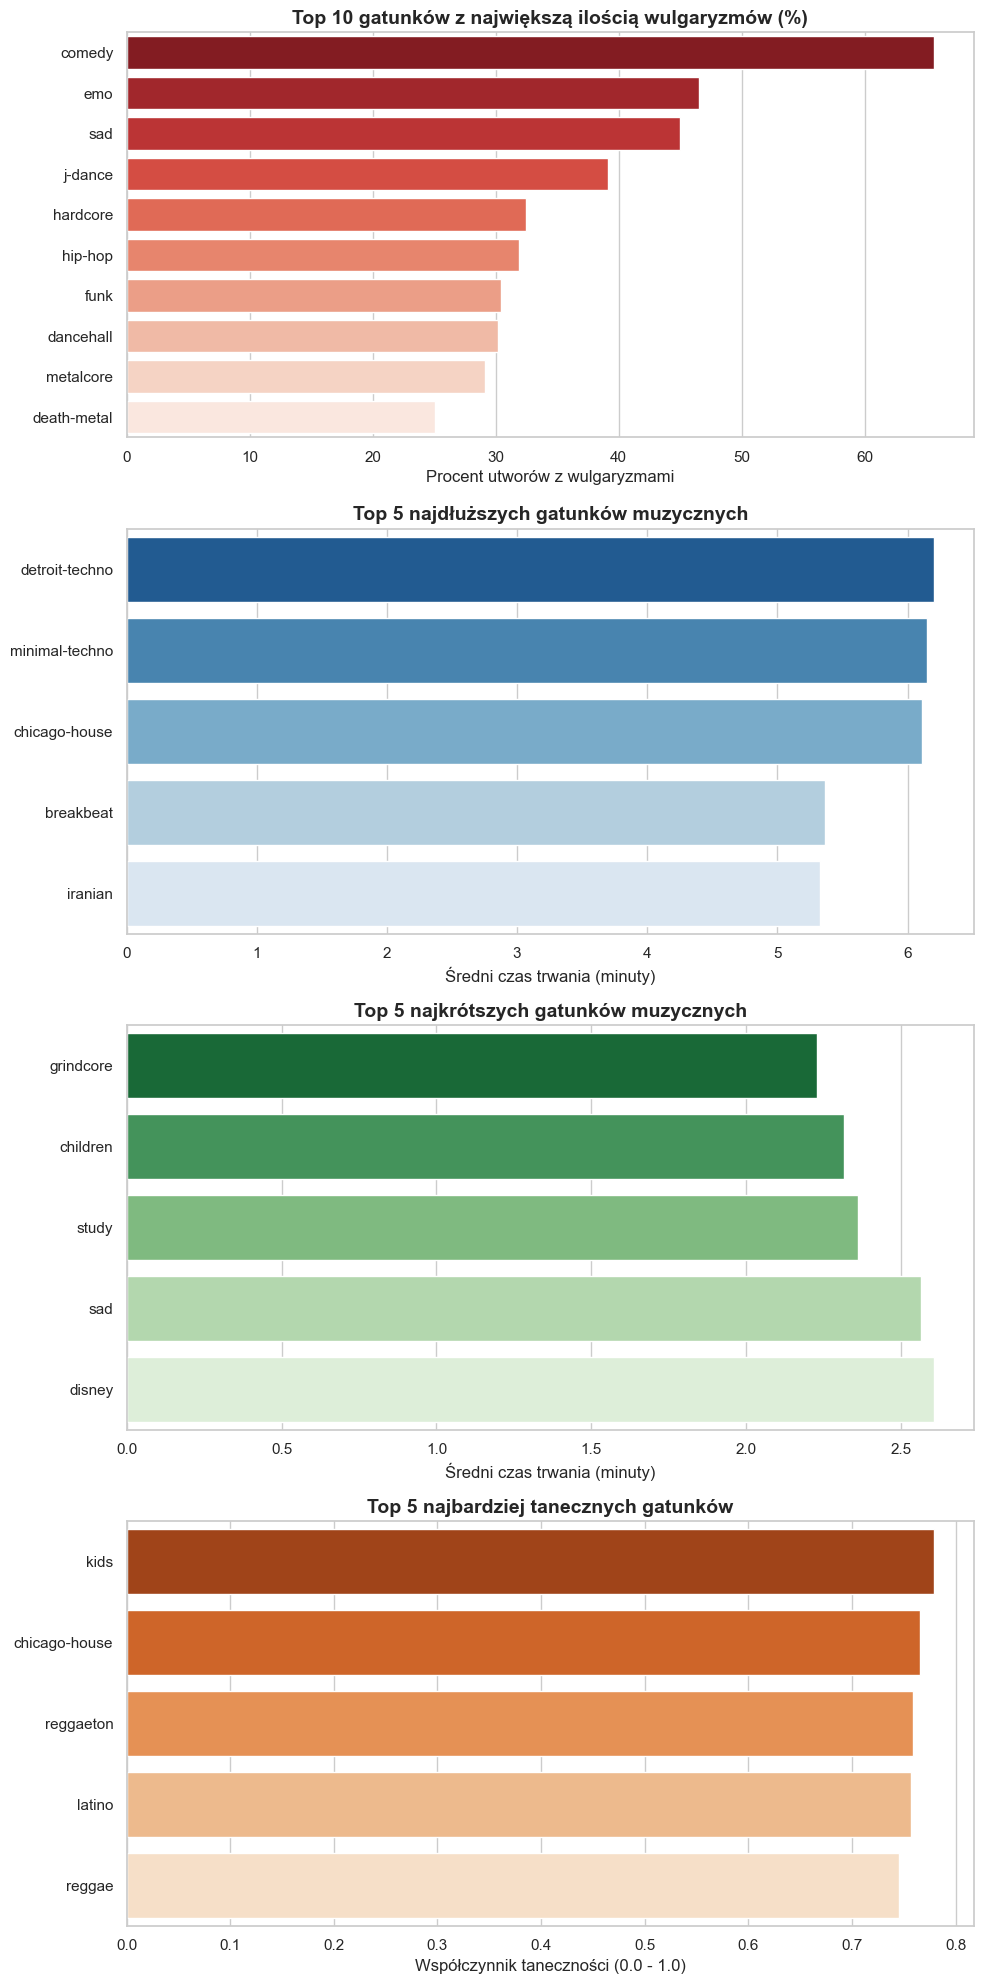

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Wykresy analityczne\n")

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(4, 1, figsize=(10, 20))

# WYKRES 1: Wulgaryzmy

sns.barplot(
    x=wulgaryzmy.values,
    y=wulgaryzmy.index,
    ax=axes[0],
    palette="Reds_r",
    hue=wulgaryzmy.index,
    legend=False
)
axes[0].set_title("Top 10 gatunków z największą ilością wulgaryzmów (%)", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Procent utworów z wulgaryzmami")
axes[0].set_ylabel("")

# WYKRES 2: Najdłuższe utwory

top_dlugie = dlugosc_minuty.sort_values(ascending=False).head(5)
sns.barplot(
    x=top_dlugie.values,
    y=top_dlugie.index,
    ax=axes[1],
    palette="Blues_r",
    hue=top_dlugie.index,
    legend=False
)
axes[1].set_title("Top 5 najdłuższych gatunków muzycznych", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Średni czas trwania (minuty)")
axes[1].set_ylabel("")


# WYKRES 3: Najkrótsze utwory

top_krotkie = dlugosc_minuty.sort_values(ascending=True).head(5)
sns.barplot(
    x=top_krotkie.values,
    y=top_krotkie.index,
    ax=axes[2],
    palette="Greens_r",
    hue=top_krotkie.index,
    legend=False
)
axes[2].set_title("Top 5 najkrótszych gatunków muzycznych", fontsize=14, fontweight='bold')
axes[2].set_xlabel("Średni czas trwania (minuty)")
axes[2].set_ylabel("")

# WYKRES 4: Taneczność

sns.barplot(
    x=tanecznosc.values,
    y=tanecznosc.index,
    ax=axes[3],
    palette="Oranges_r",
    hue=tanecznosc.index,
    legend=False
)
axes[3].set_title("Top 5 najbardziej tanecznych gatunków", fontsize=14, fontweight='bold')
axes[3].set_xlabel("Współczynnik taneczności (0.0 - 1.0)")
axes[3].set_ylabel("")

plt.tight_layout()
plt.show()